In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/guillemservera/tsla-stock-data/tsla_split_adjusted.csv
/kaggle/input/datasets/guillemservera/tsla-stock-data/tsla_raw_data.csv


In [27]:
import pandas as pd

# Dataset path
file_path = "/kaggle/input/datasets/guillemservera/tsla-stock-data/tsla_split_adjusted.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
print(df.head())

# Shape
print("Shape:", df.shape)

# Column names
print(df.columns)

         date     open     high      low    close     volume  raw_close  \
0  2010-06-29  1.26666  1.66666  1.16934  1.59266  281749173    23.8899   
1  2010-06-30  1.71934  2.02794  1.55334  1.58866  257915884    23.8299   
2  2010-07-01  1.66666  1.72800  1.35134  1.46400  123447940    21.9600   
3  2010-07-02  1.53334  1.54000  1.24734  1.28000   77127102    19.2000   
4  2010-07-06  1.33334  1.33334  1.05534  1.07400  103189435    16.1100   

   change_percent  avg_vol_20d  
0             NaN          NaN  
1           -0.25          NaN  
2           -7.85          NaN  
3          -12.57          NaN  
4          -16.09          NaN  
Shape: (3472, 9)
Index(['date', 'open', 'high', 'low', 'close', 'volume', 'raw_close',
       'change_percent', 'avg_vol_20d'],
      dtype='object')


In [28]:
df.head()

,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
0,2010-06-29,1.26666,1.66666,1.16934,1.59266,281749173,23.8899,NaN,NaN
1,2010-06-30,1.71934,2.02794,1.55334,1.58866,257915884,23.8299,-0.25,NaN
2,2010-07-01,1.66666,1.72800,1.35134,1.46400,123447940,21.9600,-7.85,NaN
3,2010-07-02,1.53334,1.54000,1.24734,1.28000,77127102,19.2000,-12.57,NaN
4,2010-07-06,1.33334,1.33334,1.05534,1.07400,103189435,16.1100,-16.09,NaN


In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [30]:
df.shape

(3472, 9)

In [31]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'raw_close',
       'change_percent', 'avg_vol_20d'],
      dtype='object')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            3472 non-null   object 
 1   open            3472 non-null   float64
 2   high            3472 non-null   float64
 3   low             3472 non-null   float64
 4   close           3472 non-null   float64
 5   volume          3472 non-null   int64  
 6   raw_close       3472 non-null   float64
 7   change_percent  3471 non-null   float64
 8   avg_vol_20d     3453 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 244.3+ KB


In [33]:
df.dtypes

date               object
open              float64
high              float64
low               float64
close             float64
volume              int64
raw_close         float64
change_percent    float64
avg_vol_20d       float64
dtype: object

In [34]:
df.describe()

,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
count,3472.000000,3472.000000,3472.000000,3472.000000,3.472000e+03,3472.000000,3471.000000,3.453000e+03
mean,73.011671,74.636430,71.293354,72.985388,9.699624e+07,305.740220,0.196765,9.696034e+07
std,102.026846,104.338314,99.544475,101.941795,7.933127e+07,289.265494,3.574390,6.331152e+07
min,1.076000,1.108660,0.998660,1.053340,1.779210e+06,15.800100,-21.060000,4.317139e+06
25%,11.184500,11.433340,10.849780,11.114835,4.671680e+07,153.360000,-1.600000,5.625444e+07
50%,17.198340,17.472330,16.885330,17.182330,8.221361e+07,232.995050,0.120000,8.969658e+07
75%,140.445833,143.604167,136.715000,140.345000,1.230786e+08,335.967450,1.920000,1.270215e+08
max,411.470000,414.496667,405.666667,409.970000,9.140814e+08,2238.750000,24.400000,3.886315e+08


# Check Missing Values

In [35]:
df.isnull().sum()

date               0
open               0
high               0
low                0
close              0
volume             0
raw_close          0
change_percent     1
avg_vol_20d       19
dtype: int64

# Convert Date Column

In [36]:
df['date'] = pd.to_datetime(df['date'])

In [37]:
df['date']

0      2010-06-29
1      2010-06-30
2      2010-07-01
3      2010-07-02
4      2010-07-06
          ...    
3467   2024-04-09
3468   2024-04-10
3469   2024-04-11
3470   2024-04-12
3471   2024-04-15
Name: date, Length: 3472, dtype: datetime64[ns]

In [38]:
df.dtypes

date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
raw_close                float64
change_percent           float64
avg_vol_20d              float64
dtype: object

In [39]:
df.head()

,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
0,2010-06-29,1.26666,1.66666,1.16934,1.59266,281749173,23.8899,NaN,NaN
1,2010-06-30,1.71934,2.02794,1.55334,1.58866,257915884,23.8299,-0.25,NaN
2,2010-07-01,1.66666,1.72800,1.35134,1.46400,123447940,21.9600,-7.85,NaN
3,2010-07-02,1.53334,1.54000,1.24734,1.28000,77127102,19.2000,-12.57,NaN
4,2010-07-06,1.33334,1.33334,1.05534,1.07400,103189435,16.1100,-16.09,NaN


In [40]:
df.isna().sum()

date               0
open               0
high               0
low                0
close              0
volume             0
raw_close          0
change_percent     1
avg_vol_20d       19
dtype: int64

In [41]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
avg_vol_20d,19,0.547235
change_percent,1,0.028802
date,0,0.000000
open,0,0.000000
high,0,0.000000
close,0,0.000000
low,0,0.000000
raw_close,0,0.000000
volume,0,0.000000


# Impute the NaN values

In [42]:
# Check missing values
print(df.isnull().sum())

# Fill first change_percent with 0
df['change_percent'] = df['change_percent'].fillna(0)

# Remove first 19 rows where 20-day average cannot exist
df = df.dropna(subset=['avg_vol_20d'])

# Verify no missing values remain
print(df.isnull().sum())

date               0
open               0
high               0
low                0
close              0
volume             0
raw_close          0
change_percent     1
avg_vol_20d       19
dtype: int64
date              0
open              0
high              0
low               0
close             0
volume            0
raw_close         0
change_percent    0
avg_vol_20d       0
dtype: int64


# Detect Outliers

In [43]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)

IQR=Q3-Q1

outliers=((df<(Q1-1.5*IQR))) |((df>(Q3+1.5*IQR))).sum()
print(outliers)


       date  open  high   low  close  volume  raw_close  change_percent  \
19    False  True  True  True   True    True       True            True   
20    False  True  True  True   True    True       True            True   
21    False  True  True  True   True    True       True            True   
22    False  True  True  True   True    True       True            True   
23    False  True  True  True   True    True       True            True   
...     ...   ...   ...   ...    ...     ...        ...             ...   
3467  False  True  True  True   True    True       True            True   
3468  False  True  True  True   True    True       True            True   
3469  False  True  True  True   True    True       True            True   
3470  False  True  True  True   True    True       True            True   
3471  False  True  True  True   True    True       True            True   

      avg_vol_20d  
19           True  
20           True  
21           True  
22           True  

In [44]:
df.isnull().sum()

date              0
open              0
high              0
low               0
close             0
volume            0
raw_close         0
change_percent    0
avg_vol_20d       0
dtype: int64

In [45]:
nan_rows = df[df.isnull().any(axis=1)]

for idx in nan_rows.index:
    print(f"Row {idx}:")
    print(nan_rows.loc[idx][nan_rows.loc[idx].isnull()])
    print("-" * 40)

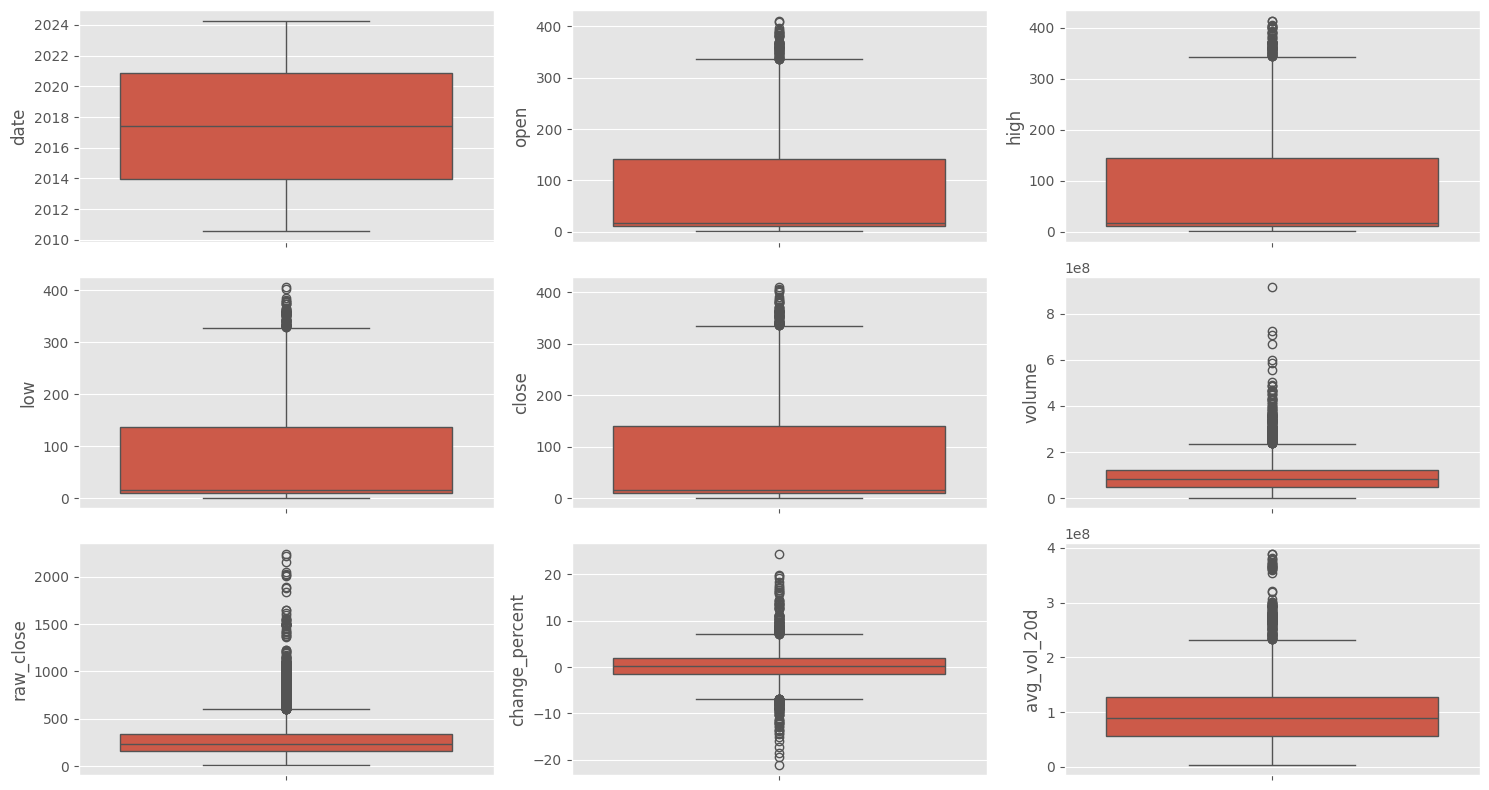

In [46]:
plt.figure(figsize=(15,8))

for i,col in enumerate(df.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

In [47]:
# Fill first day's percentage change
df['change_percent'] = df['change_percent'].fillna(0)

# Remove rows where 20-day average cannot be calculated
df = df.dropna(subset=['avg_vol_20d'])

In [48]:
print(df.isnull().sum())

date              0
open              0
high              0
low               0
close             0
volume            0
raw_close         0
change_percent    0
avg_vol_20d       0
dtype: int64


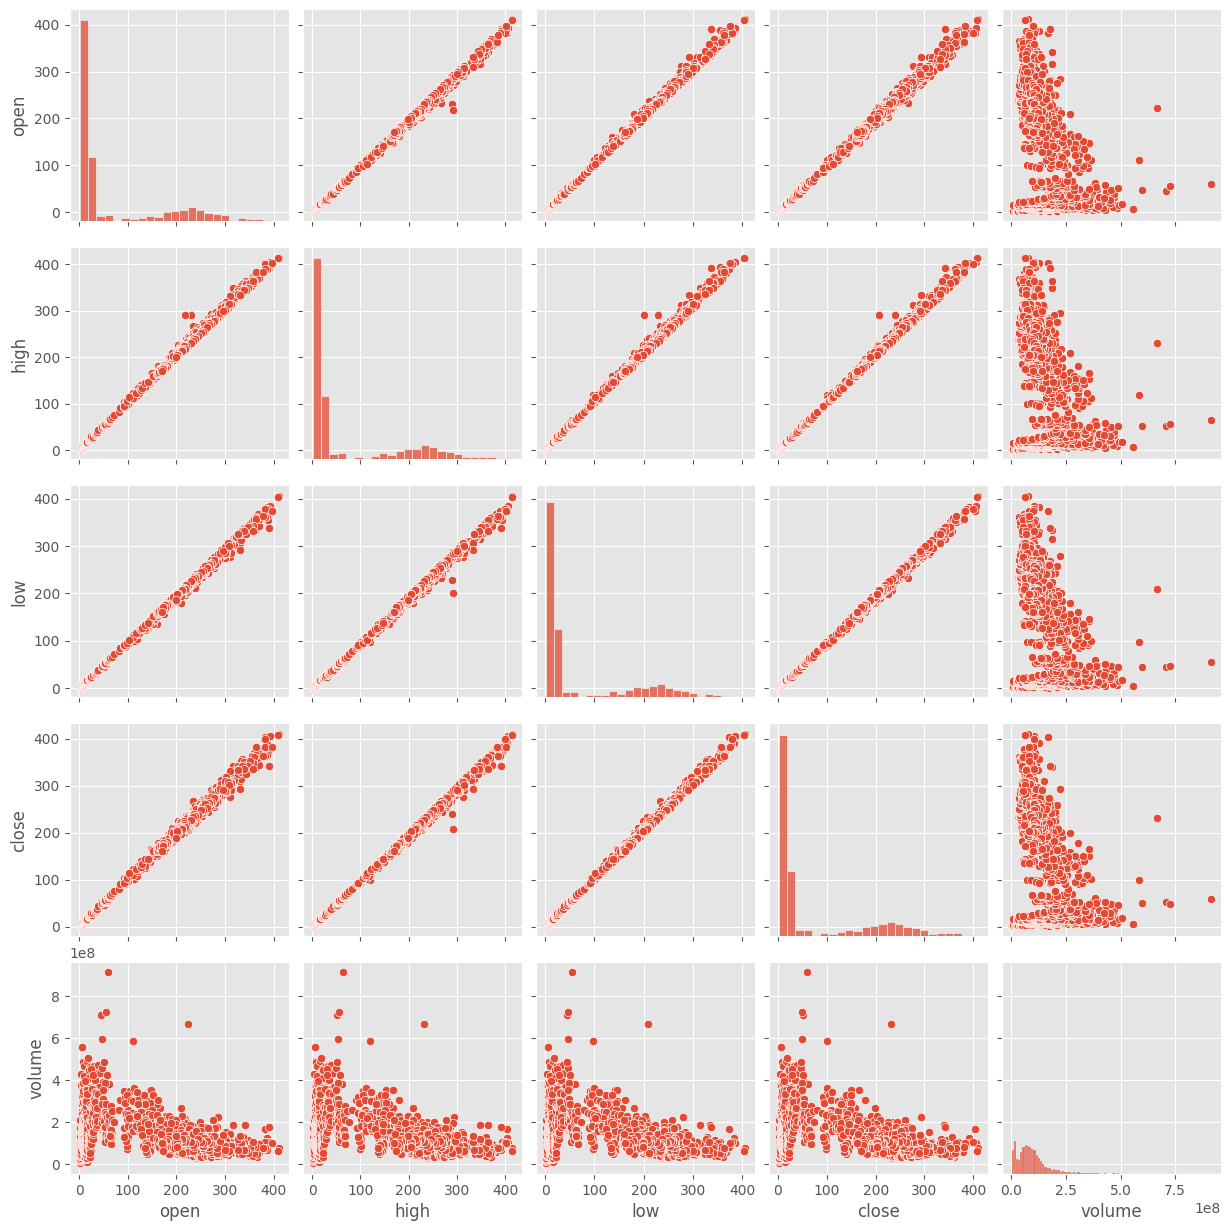

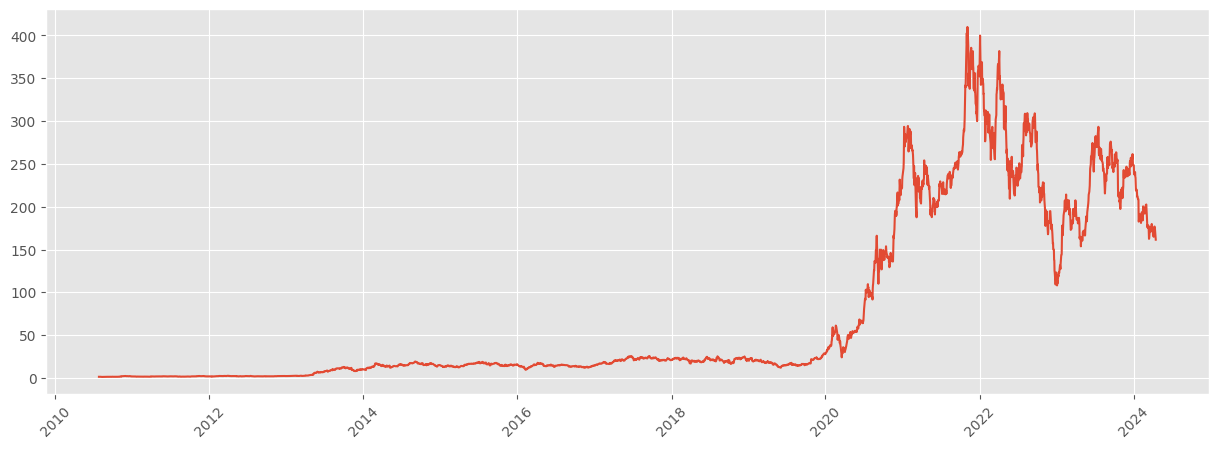

In [49]:
sns.pairplot(df[['open','high','low','close','volume']])

# 10. Time Series Plot
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['close'])
plt.xticks(rotation=45)
plt.show()

# Method 1: Find Outliers Using the IQR Method (Recommended)

In [50]:
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"Column: {column}")
    print(f"Lower Limit: {lower:.2f}")
    print(f"Upper Limit: {upper:.2f}")
    print(f"Number of Outliers: {len(outliers)}")

    return outliers

In [51]:
outliers_open = find_outliers(df, 'open')
outliers_open.head()

Column: open
Lower Limit: -183.33
Upper Limit: 336.00
Number of Outliers: 62


,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
2852,2021-10-26,341.563333,364.980000,333.813333,339.476667,187244902,1018.43,-0.63,70826296.85
2853,2021-10-27,346.553333,356.960000,343.593333,345.953333,115579380,1037.86,1.91,73463833.80
2854,2021-10-28,356.101667,360.333333,351.400000,359.013333,81639502,1077.04,3.78,74852414.85
2855,2021-10-29,360.620000,371.736667,357.735000,371.333333,89755257,1114.00,3.43,76785466.25
2856,2021-11-01,381.666667,403.250000,372.886667,402.863333,168146152,1208.59,8.49,80620273.00


# Method 2: Check All Numeric Columns

In [52]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col:<20} {count}")

open                 62
high                 66
low                  63
close                66
volume               194
raw_close            545
change_percent       192
avg_vol_20d          137


In [53]:
Q1 = df['close'].quantile(0.25)
Q3 = df['close'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['close'] < lower) | (df['close'] > upper)]

outliers

,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
2851,2021-10-25,316.843333,348.340000,314.733333,341.620000,188556289,1024.86,12.66,65271264.65
2852,2021-10-26,341.563333,364.980000,333.813333,339.476667,187244902,1018.43,-0.63,70826296.85
2853,2021-10-27,346.553333,356.960000,343.593333,345.953333,115579380,1037.86,1.91,73463833.80
2854,2021-10-28,356.101667,360.333333,351.400000,359.013333,81639502,1077.04,3.78,74852414.85
2855,2021-10-29,360.620000,371.736667,357.735000,371.333333,89755257,1114.00,3.43,76785466.25
...,...,...,...,...,...,...,...,...,...
2965,2022-04-07,350.796667,358.863333,340.513333,352.420000,79447048,1057.26,1.10,78291272.60
2966,2022-04-08,347.736667,349.480000,340.811667,341.830000,55013698,1025.49,-3.00,77690099.45
2969,2022-04-13,327.025033,342.080000,324.365667,340.790000,55121218,1022.37,3.59,75611714.60
2972,2022-04-19,335.020000,344.980000,331.775033,342.716667,49847816,1028.15,2.38,71162047.40


In [54]:
Q1 = df['close'].quantile(0.25)
Q3 = df['close'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['close'] < lower) | (df['close'] > upper)]

outliers[['date', 'open', 'high', 'low', 'close']]

,date,open,high,low,close
2851,2021-10-25,316.843333,348.340000,314.733333,341.620000
2852,2021-10-26,341.563333,364.980000,333.813333,339.476667
2853,2021-10-27,346.553333,356.960000,343.593333,345.953333
2854,2021-10-28,356.101667,360.333333,351.400000,359.013333
2855,2021-10-29,360.620000,371.736667,357.735000,371.333333
...,...,...,...,...,...
2965,2022-04-07,350.796667,358.863333,340.513333,352.420000
2966,2022-04-08,347.736667,349.480000,340.811667,341.830000
2969,2022-04-13,327.025033,342.080000,324.365667,340.790000
2972,2022-04-19,335.020000,344.980000,331.775033,342.716667


In [55]:
df.sort_values('change_percent', ascending=False).head(10)

,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
720,2013-05-09,4.674660,5.05134,4.246000,4.626660,429074516,69.3999,24.40,7.599264e+07
2415,2020-02-03,44.912680,52.40934,44.901340,52.000000,708502469,780.0000,19.89,3.211390e+08
2691,2021-03-09,202.726667,226.03000,198.403333,224.526667,202569978,673.5800,19.64,1.134031e+08
94,2010-11-10,1.632000,1.99800,1.603340,1.957340,45915568,29.3601,19.20,9.064548e+06
2447,2020-03-19,24.979800,30.13334,23.897340,28.509340,452931895,427.6401,18.39,2.853431e+08
2347,2019-10-24,19.891340,20.32866,19.280000,19.978660,447288430,299.6799,17.67,1.319392e+08
2079,2018-10-01,20.384660,20.76266,20.070000,20.713340,326663986,310.7001,17.35,1.633898e+08
191,2011-03-31,1.770000,1.91400,1.766660,1.850000,172835092,27.7500,17.04,2.261854e+07
391,2012-01-17,1.774660,1.82266,1.760660,1.773340,69785787,26.6001,16.72,1.877050e+07
864,2013-12-03,8.845340,9.66266,8.772660,9.646660,385235983,144.6999,16.53,2.411524e+08


In [56]:
df.sort_values('change_percent').head(10)

,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d
2566,2020-09-08,118.666667,122.913333,109.96000,110.07000,346397075,330.2100,-21.06,2.751734e+08
390,2012-01-13,1.893340,1.900000,1.50934,1.51934,82596566,22.7901,-19.33,1.580641e+07
2444,2020-03-16,31.299980,32.991340,29.47800,29.67134,307341901,445.0701,-18.58,2.716782e+08
2417,2020-02-05,54.884000,56.398660,46.94072,48.98000,726357568,734.7000,-17.18,3.818860e+08
2446,2020-03-18,25.933340,26.990660,23.36734,24.08134,356792384,361.2201,-16.03,2.759227e+08
125,2010-12-27,1.868000,1.905340,1.67066,1.70326,139534929,25.5489,-15.09,2.207633e+07
846,2013-11-06,10.320660,10.715340,9.75700,10.07734,466075914,151.1601,-14.51,1.687466e+08
766,2013-07-16,8.418660,8.421340,7.15334,7.27000,485578014,109.0500,-14.31,1.433068e+08
2078,2018-09-28,18.017340,18.533340,17.37034,17.65134,504745298,264.7701,-13.90,1.510879e+08
2283,2019-07-25,15.566660,15.633340,15.03668,15.25466,336273705,228.8199,-13.61,1.319807e+08


# Scale data

In [57]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df[['open','high','low','close','volume']])

In [58]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'raw_close',
       'change_percent', 'avg_vol_20d'],
      dtype='object')

In [59]:
df['open']

19        1.39400
20        1.37000
21        1.38466
22        1.34666
23        1.36666
          ...    
3467    172.91000
3468    173.04000
3469    172.55000
3470    172.34000
3471    170.24000
Name: open, Length: 3453, dtype: float64

In [60]:
df['high']

19        1.41200
20        1.39334
21        1.39200
22        1.36266
23        1.39800
          ...    
3467    179.22000
3468    174.93000
3469    175.88000
3470    173.80990
3471    170.69000
Name: high, Length: 3453, dtype: float64

# Closing Price Trend

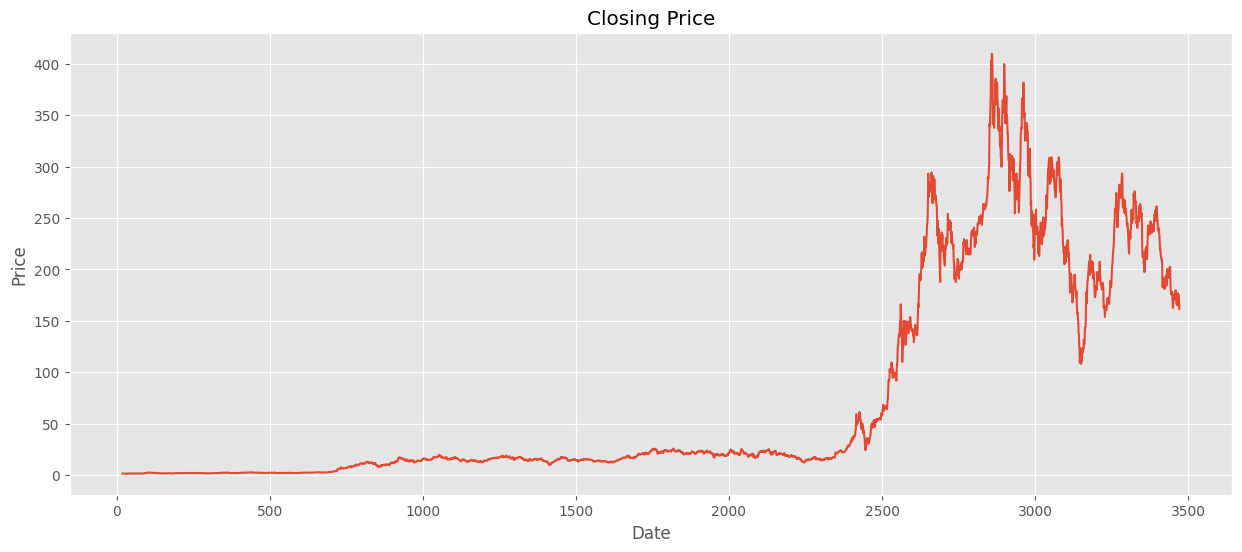

In [61]:
plt.figure(figsize=(15,6))

plt.plot(df.index,df['close'])

plt.title("Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

# Opening Price Trend

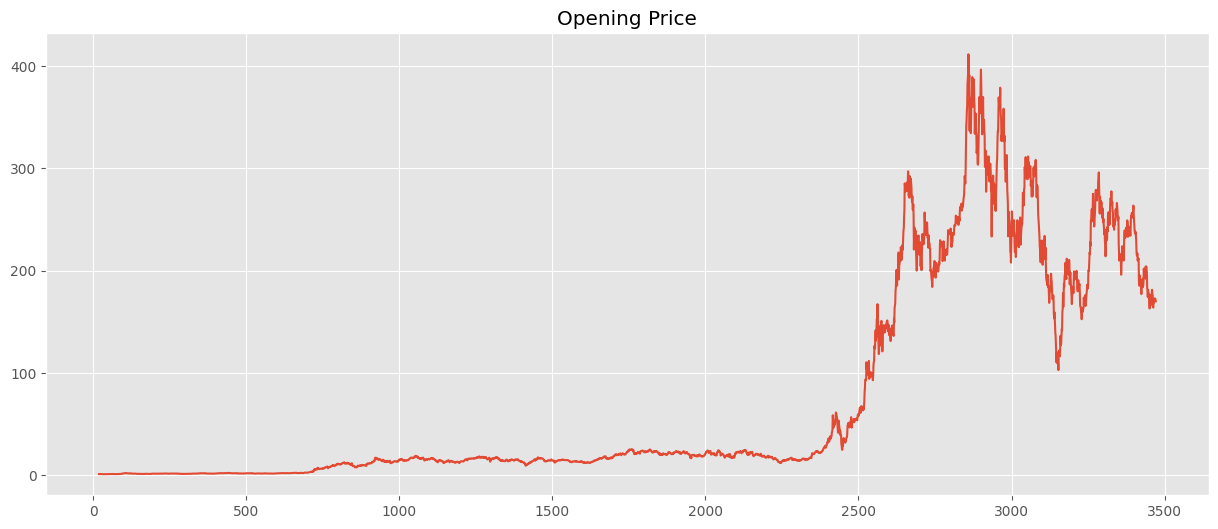

In [62]:
plt.figure(figsize=(15,6))

plt.plot(df.index,df['open'])

plt.title("Opening Price")

plt.show()

# Volume Trend

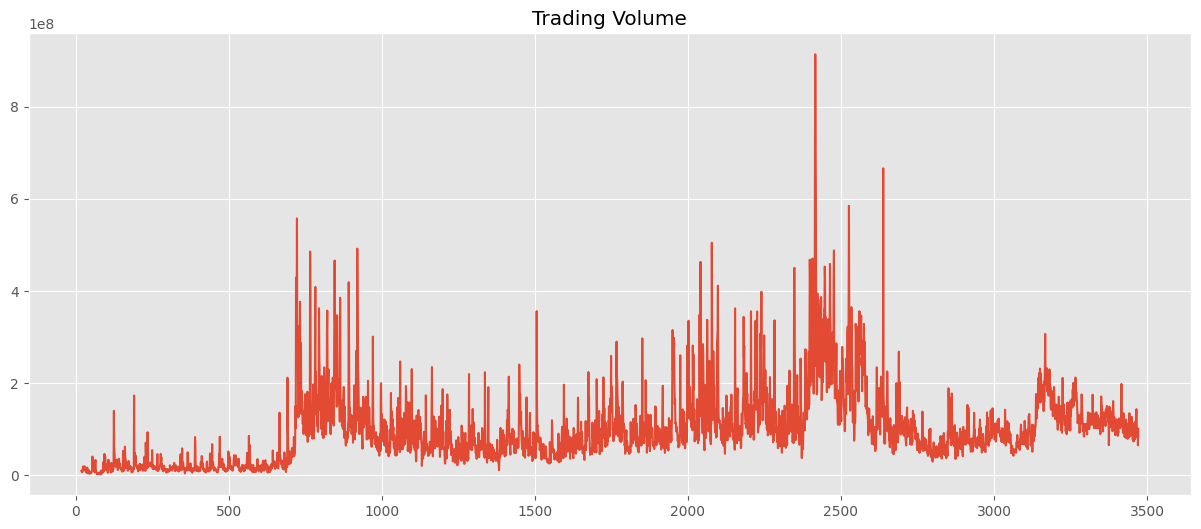

In [63]:
plt.figure(figsize=(15,6))

plt.plot(df.index,df['volume'])

plt.title("Trading Volume")

plt.show()

# High vs Low Price

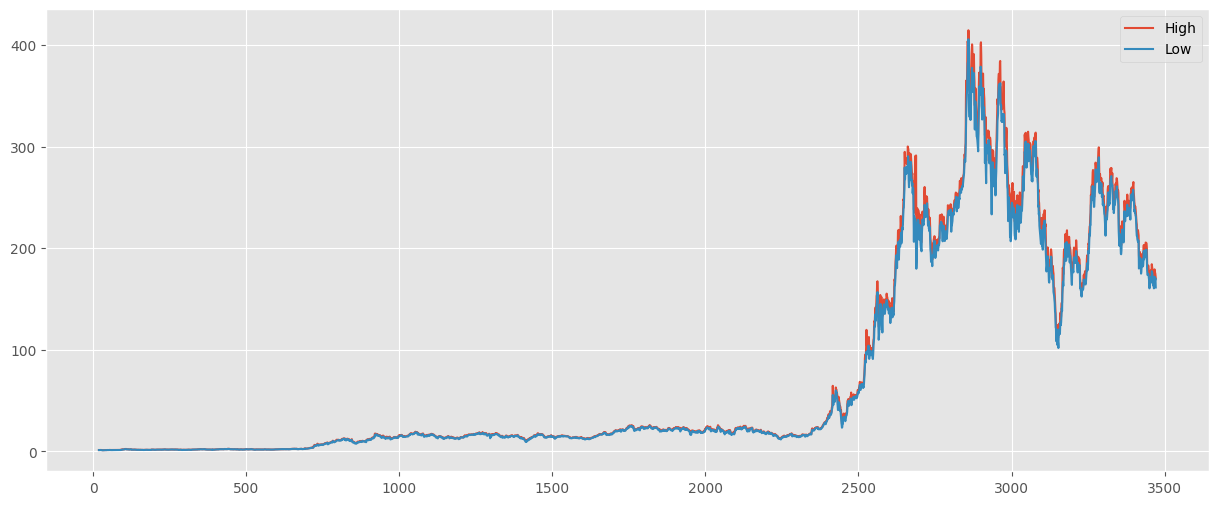

In [64]:
plt.figure(figsize=(15,6))

plt.plot(df.index,df['high'],label="High")
plt.plot(df.index,df['low'],label="Low")

plt.legend()

plt.show()

# Close vs Open

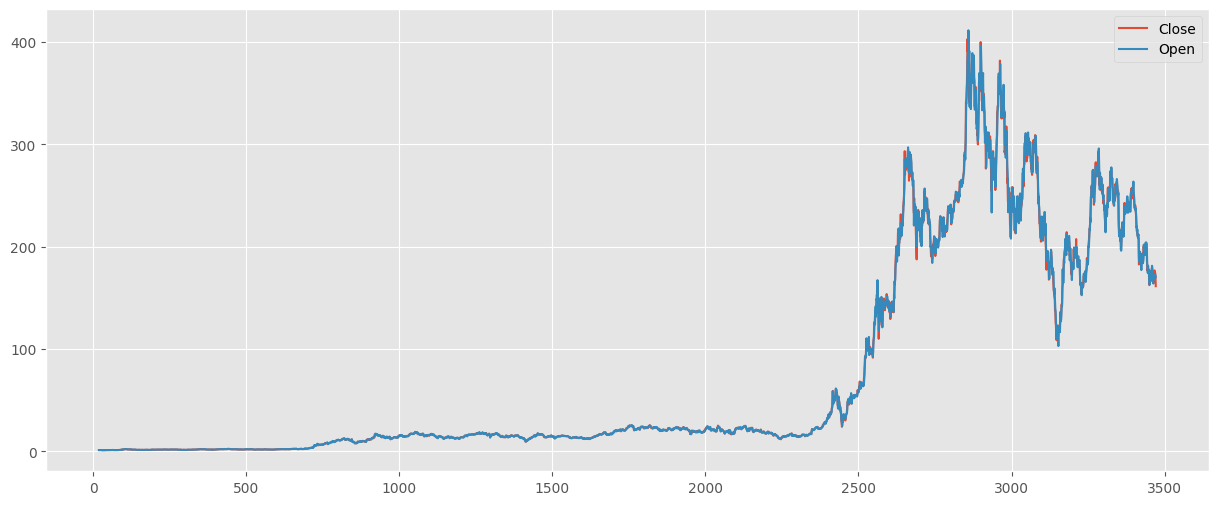

In [65]:
plt.figure(figsize=(15,6))

plt.plot(df.index,df['close'],label="Close")
plt.plot(df.index,df['open'],label="Open")

plt.legend()

plt.show()

# 1. Rolling_Mean

**What is it?**

The average stock price over the last N days.

If your rolling window is 5 days, then:

Rolling Mean=
5
Last 5 Close Prices
	​

**Example**

Suppose the closing prices are:

Day	Close
1	100
2	102
3	104
4	106
5	108

Rolling Mean (5 days)

=
5
100+102+104+106+108
	​

=104

So on Day 5,

Rolling_Mean = 104
Python
**df['Rolling_Mean'] = df['close'].rolling(window=5).mean()**

# Why do we use it?

It smooths the stock prices.

Instead of looking at every day's ups and downs, you see the overall trend.

Example

Without Rolling Mean

100
105
98
110
101
95
107

Very noisy

Rolling Mean

100
101
102
103
104
105

Smooth trend

# Rolling Mean (30 Days)

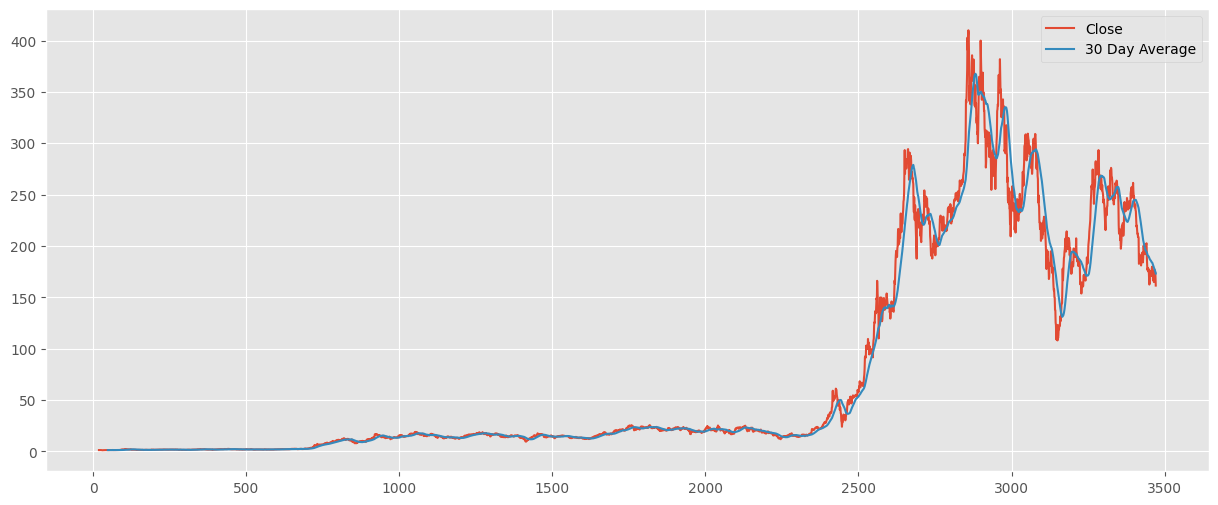

In [66]:
df['Rolling_Mean']=df['close'].rolling(30).mean()

plt.figure(figsize=(15,6))

plt.plot(df['close'])

plt.plot(df['Rolling_Mean'])

plt.legend(["Close","30 Day Average"])

plt.show()

# Rolling Standard Deviation

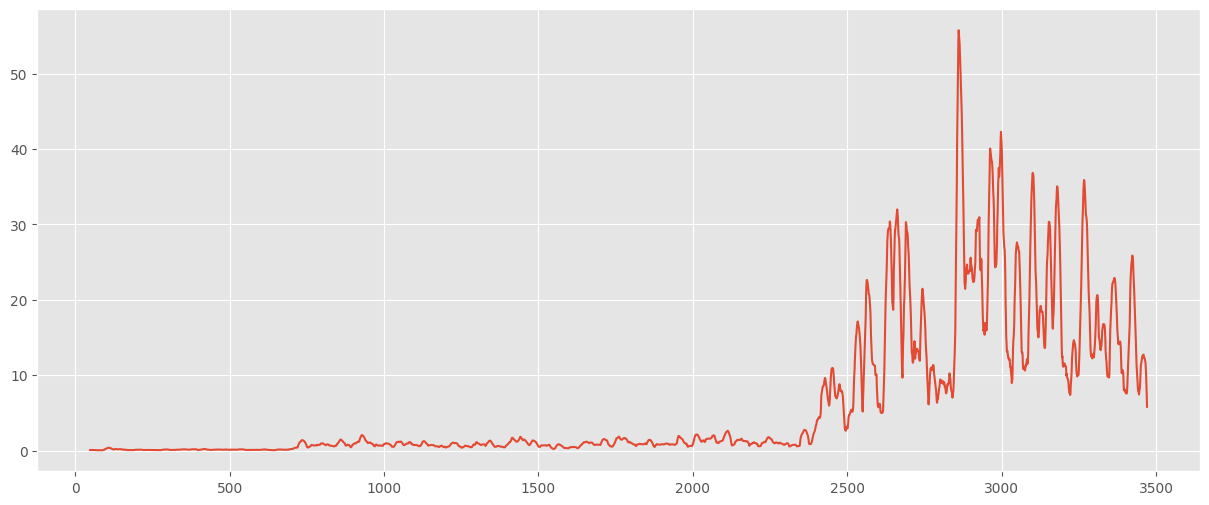

In [67]:
df['Rolling_STD']=df['close'].rolling(30).std()

plt.figure(figsize=(15,6))

plt.plot(df['Rolling_STD'])

plt.show()

# Daily Returns

In [68]:
df['Daily_Return']=df['close'].pct_change()

df.head()

,date,open,high,low,close,volume,raw_close,change_percent,avg_vol_20d,Rolling_Mean,Rolling_STD,Daily_Return
19,2010-07-27,1.39400,1.41200,1.35066,1.37000,9295125,20.5500,-1.91,74326218.50,NaN,NaN,NaN
20,2010-07-28,1.37000,1.39334,1.36734,1.38134,7007745,20.7201,0.82,60589147.10,NaN,NaN,0.008277
21,2010-07-29,1.38466,1.39200,1.33334,1.35666,9238650,20.3499,-1.78,48155285.40,NaN,NaN,-0.017867
22,2010-07-30,1.34666,1.36266,1.30334,1.32934,6402450,19.9401,-2.02,42303010.90,NaN,NaN,-0.020138
23,2010-08-02,1.36666,1.39800,1.35554,1.39466,10787175,20.9199,4.92,38986014.55,NaN,NaN,0.049137


# Daily Return Distribution

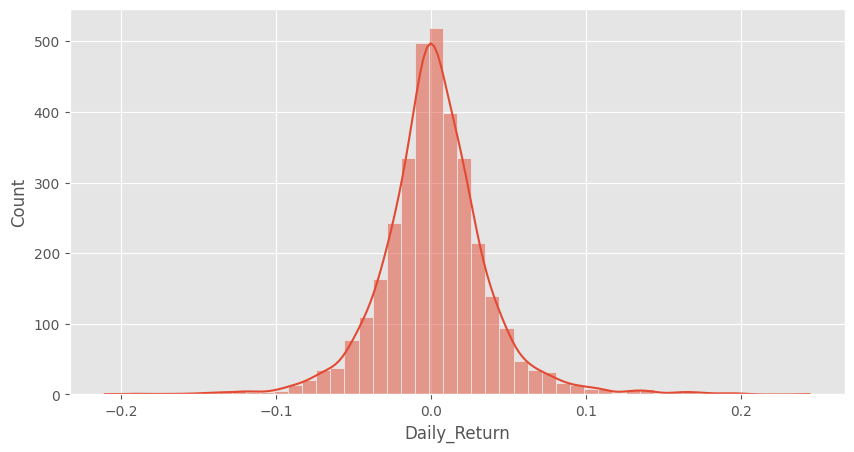

In [69]:
plt.figure(figsize=(10,5))

sns.histplot(df['Daily_Return'],bins=50,kde=True)

plt.show()

# Moving Average (50 Days)

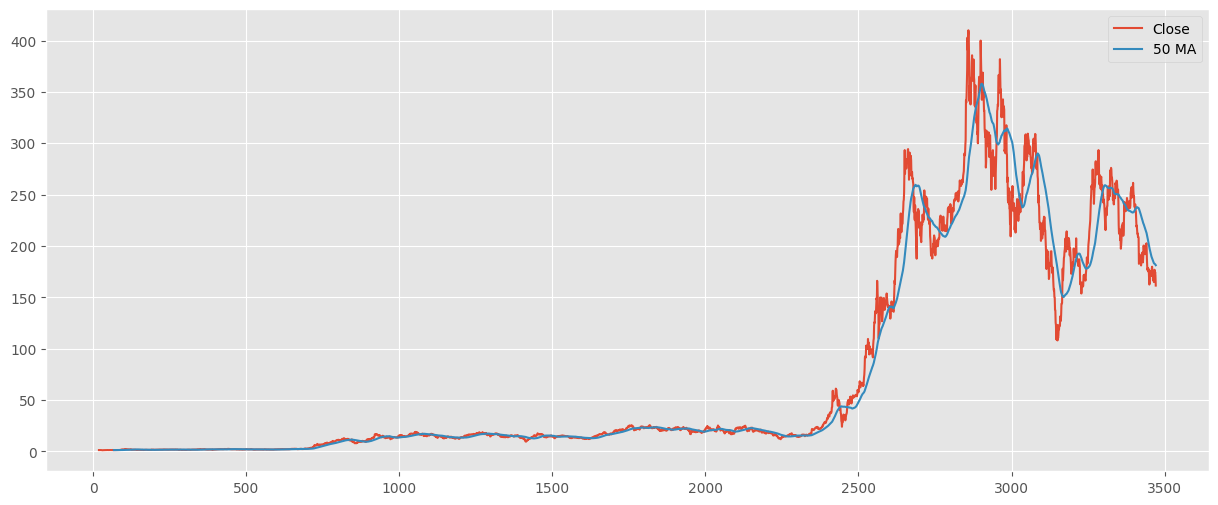

In [70]:
df['MA50']=df['close'].rolling(50).mean()

plt.figure(figsize=(15,6))

plt.plot(df['close'])

plt.plot(df['MA50'])

plt.legend(["Close","50 MA"])

plt.show()

# Moving Average (100 Days)

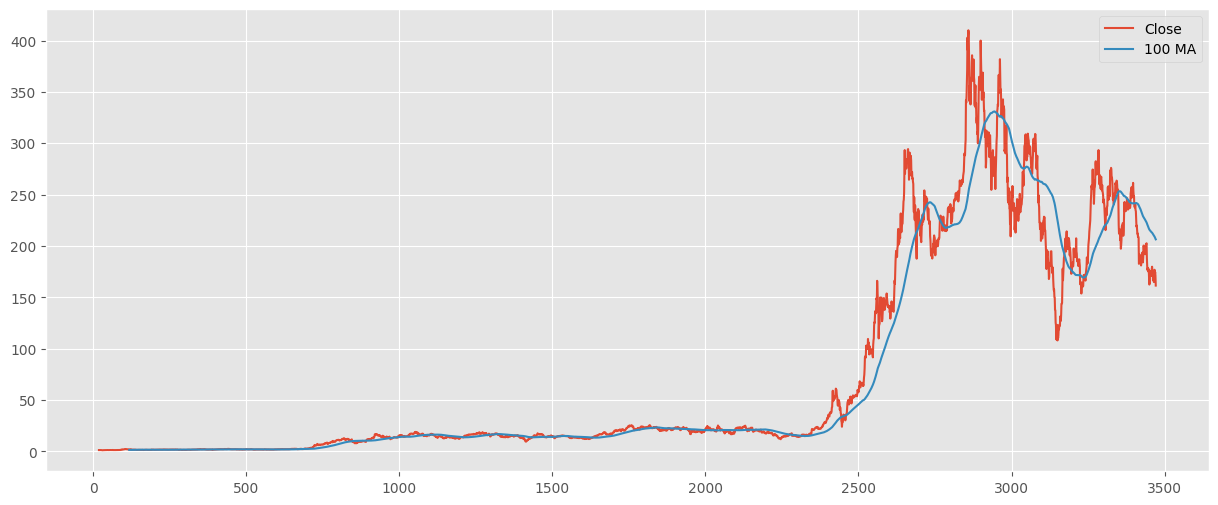

In [71]:
df['MA100']=df['close'].rolling(100).mean()

plt.figure(figsize=(15,6))

plt.plot(df['close'])

plt.plot(df['MA100'])

plt.legend(["Close","100 MA"])

plt.show()

# Moving Average (200 Days)

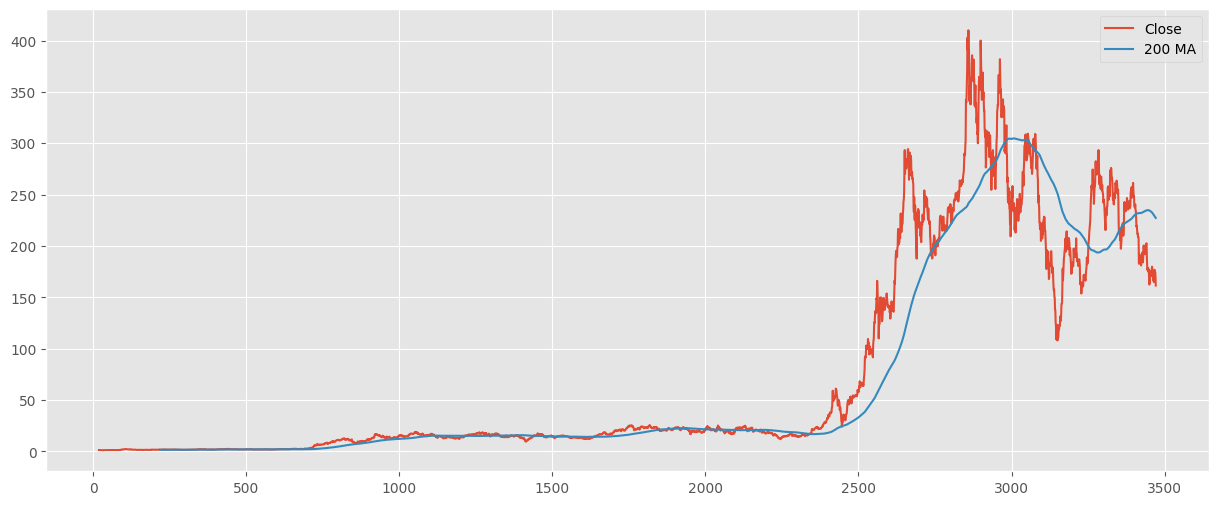

In [72]:
df['MA200']=df['close'].rolling(200).mean()

plt.figure(figsize=(15,6))

plt.plot(df['close'])

plt.plot(df['MA200'])

plt.legend(["Close","200 MA"])

plt.show()

# Candlestick Chart

In [73]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df.index,
    open=df['open'],
    high=df['high'],
    low=df['low'],
    close=df['close']
)])

fig.show()

In [74]:
df.shape

(3453, 15)

In [76]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'raw_close',
       'change_percent', 'avg_vol_20d', 'Rolling_Mean', 'Rolling_STD',
       'Daily_Return', 'MA50', 'MA100', 'MA200'],
      dtype='object')

# Volume Distribution